# SAM 3 — concept segmentation & streaming video tracking

SAM 3 segments by **concept**: a text phrase, a box, or a click. This notebook walks the
whole integration on one clip:

1. **Base SAM 3 video** — text concept, click seeding, box seeding, negative boxes
2. **Base SAM 3 image** — genuine DETR detections, threshold and phrase sweeps
3. **Multiplex SAM 3.1 video** — the same API, up to 16 objects in one joint pass,
   mid-stream spawn, box prompts
4. **Output policy (`Emit`)** and **tracking several concepts at once**

Requires a CUDA GPU, `checkpoints/sam3.pt` and `checkpoints/sam3.1_multiplex.pt`
(`pixi run download-sam3` / `download-sam3-1`; the weights are access-gated by Meta).

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.ops import masks_to_boxes

# Dark figures: PyCharm's dark theme inverts light-background image outputs.
plt.style.use("dark_background")

# SAM 3 owns its preprocessing on GPU (CPU resize fails parity).
assert torch.cuda.is_available(), "SAM 3 requires a CUDA GPU"
device = torch.device("cuda")

# Allow running from notebooks/: paths below are repo-root relative.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd(), "| GPU:", torch.cuda.get_device_name(0))

cwd: C:\Users\javerlia\PycharmProjects\sam2 | GPU: NVIDIA GeForce RTX 3090


In [2]:
def show_mask(mask, ax, obj_id=None):
    """Overlay a boolean mask, coloured by object id (tab10)."""
    if isinstance(mask, torch.Tensor):
        mask = mask.detach().cpu().numpy()
    cmap = plt.get_cmap("tab10")
    color = np.array([*cmap(0 if obj_id is None else obj_id % 10)[:3], 0.6])
    h, w = mask.shape[-2:]
    ax.imshow(mask.reshape(h, w, 1) * color.reshape(1, 1, -1))


def show_box(box, ax, obj_id=None, label=None):
    """Draw an xyxy box, coloured by object id, with an optional text label."""
    if isinstance(box, torch.Tensor):
        box = box.detach().cpu().numpy()
    x0, y0, x1, y1 = box
    cmap = plt.get_cmap("tab10")
    color = cmap(0 if obj_id is None else obj_id % 10)[:3]
    ax.add_patch(
        plt.Rectangle((x0, y0), x1 - x0, y1 - y0, edgecolor=color, facecolor="none", lw=2)
    )
    if label is not None:
        ax.text(x0, max(y0 - 4, 2), label, color="white", fontsize=9,
                bbox=dict(facecolor=color, edgecolor="none", pad=1))


def box_from_mask(mask_bool):
    """xyxy (pixel) box of a single boolean mask via torchvision, or None if empty."""
    if mask_bool.sum() == 0:
        return None
    return masks_to_boxes(mask_bool[None].to(torch.uint8))[0]


def collect(predictor, state, frames, geometry_prompts_frame0=None):
    """Stream `frames` through a SAM 3 video `predictor`; return per-frame {obj_id: {mask, box}}."""
    per_frame = []
    for i, fr in enumerate(frames):
        gp = geometry_prompts_frame0 if (i == 0 and geometry_prompts_frame0) else []
        with torch.inference_mode():
            results = predictor.forward(state, i, fr, geometry_prompts=gp)
        objs = {}
        for obj_id, res in results.items():
            mask = (res.best_mask_logits[0, 0] > 0).cpu()
            objs[obj_id] = {"mask": mask, "box": box_from_mask(mask)}
        per_frame.append(objs)
    return per_frame


def show_tracking(frames, per_frame, title, label_prefix, idxs=None):
    """Plot mask + derived box overlays for a few frames; colour is stable per obj id."""
    idxs = idxs or [0, len(frames) // 2, len(frames) - 1]
    fig, axes = plt.subplots(1, len(idxs), figsize=(6 * len(idxs), 5))
    fig.suptitle(title)
    for ax, i in zip(np.atleast_1d(axes), idxs):
        ax.set_title(f"frame {i}")
        ax.imshow(frames[i])
        ax.axis("off")
        for obj_id, o in per_frame[i].items():
            show_mask(o["mask"], ax, obj_id=obj_id)
            if o["box"] is not None:
                show_box(o["box"], ax, obj_id=obj_id, label=f"{label_prefix} #{obj_id}")
    plt.tight_layout()
    plt.show()

## Load the `bedroom` frames

30 frames @ 960x540


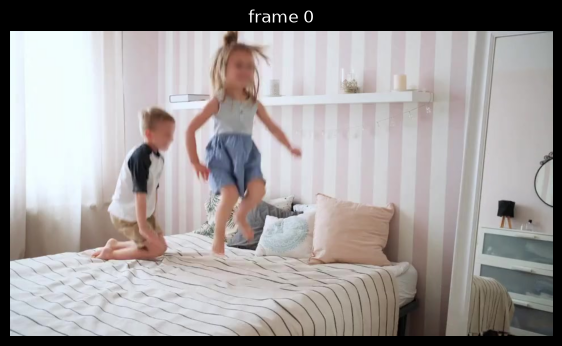

In [3]:
BEDROOM = Path("notebooks/videos/bedroom")
N_FRAMES = 30  # first N frames; the clip has 200

frame_paths = sorted(BEDROOM.glob("*.jpg"))[:N_FRAMES]
frames = [np.asarray(Image.open(p).convert("RGB")) for p in frame_paths]
H, W, _ = frames[0].shape
print(f"{len(frames)} frames @ {W}x{H}")

plt.figure(figsize=(7, 4))
plt.title("frame 0")
plt.imshow(frames[0])
plt.axis("off")
plt.show()

## 1. Non-multiplex SAM 3 — text-concept video tracking

Composes the shared PE encoder + text tower + DETR detector + per-object tracker from
`configs/sam3/sam3.yaml` and strict-loads `checkpoints/sam3.pt`. Set the text concept **once**
before the first frame, then call `forward(state, i, frame)` per frame; each call returns
`dict[obj_id -> MaskletResult]`.

In [4]:
from sam.build_sam import build_sam3_video_predictor
from sam.models.sam3_predictor import Sam3VideoPredictorState
from sam.prompts import ConceptPrompt, GeometryPrompt

video_predictor = build_sam3_video_predictor(
    config_file="configs/sam3/sam3.yaml",
    ckpt_path="checkpoints/sam3.pt",
    device="cuda",
)
print(f"loaded: {sum(p.numel() for p in video_predictor.parameters()) / 1e6:.0f}M params")

loaded: 860M params


tracked ids on last frame: [0, 1]


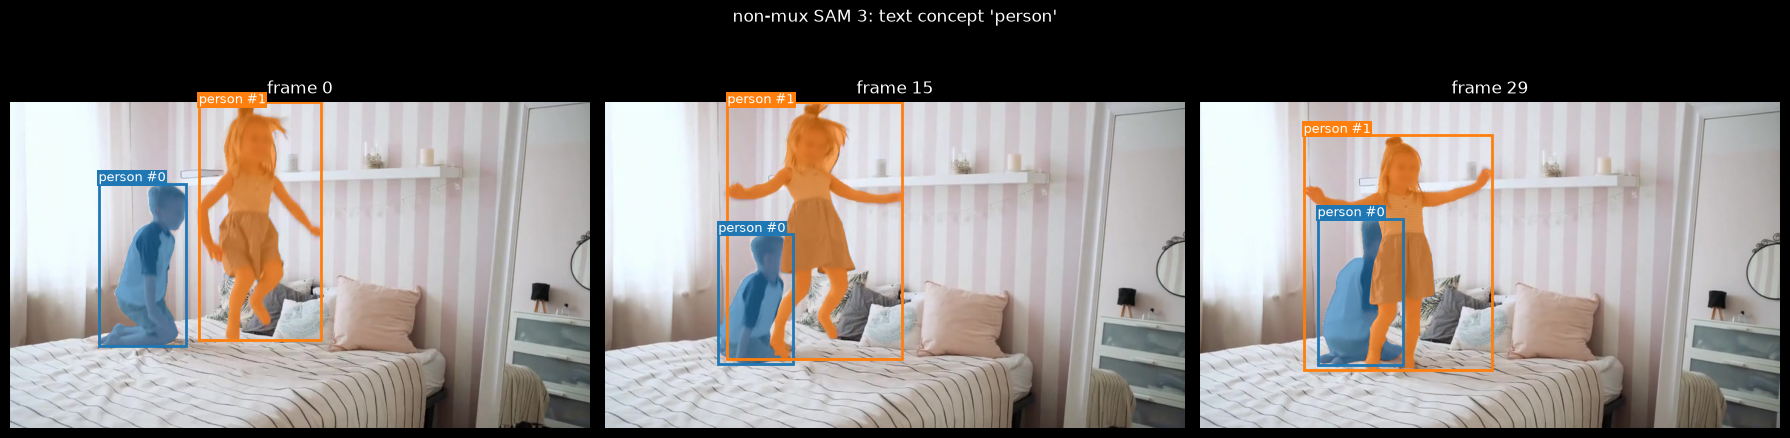

In [5]:
CONCEPT = "person"

state = Sam3VideoPredictorState(video_hw=(H, W))
video_predictor.set_concept(state, ConceptPrompt(CONCEPT))
text_track = collect(video_predictor, state, frames)
print(f"tracked ids on last frame: {sorted(text_track[-1])}")
show_tracking(frames, text_track, f"non-mux SAM 3: text concept '{CONCEPT}'", CONCEPT)

### Geometry prompting (click / box) — interactive VOS, no text

The base video predictor also takes `GeometryPrompt`s, and the two kinds take different
routes inside the model, matching upstream:

* **Clicks** go to the tracker's prompt encoder and seed an object directly — SAM 2-style
  interactive VOS. Detection stays gated off (a click adopts no concept), so the clicked
  object is the only one tracked. A clicked tracklet is also force-confirmed and exempt from
  the hotstart kill, exactly as upstream's `add_tracker_new_points` marks it: with detection
  off nothing can ever re-match it, and without that exemption the lifecycle would purge it
  after 8 frames (`tests/parity/test_sam3_interactive_parity.py` gates all 30 frames against
  the upstream golden).
* **Boxes** go to the detector's *geometric slot*: they bias that frame's detection, and the
  boxed instance seeds a tracklet through the normal association path. A box also switches
  detection on for the whole session under a placeholder caption, so other instances it
  matches get tracked too.

Here we set **no** concept and seed a single positive click on frame 0 (`label=1`), so only
that object is tracked — and it keeps being tracked to the end of the clip.

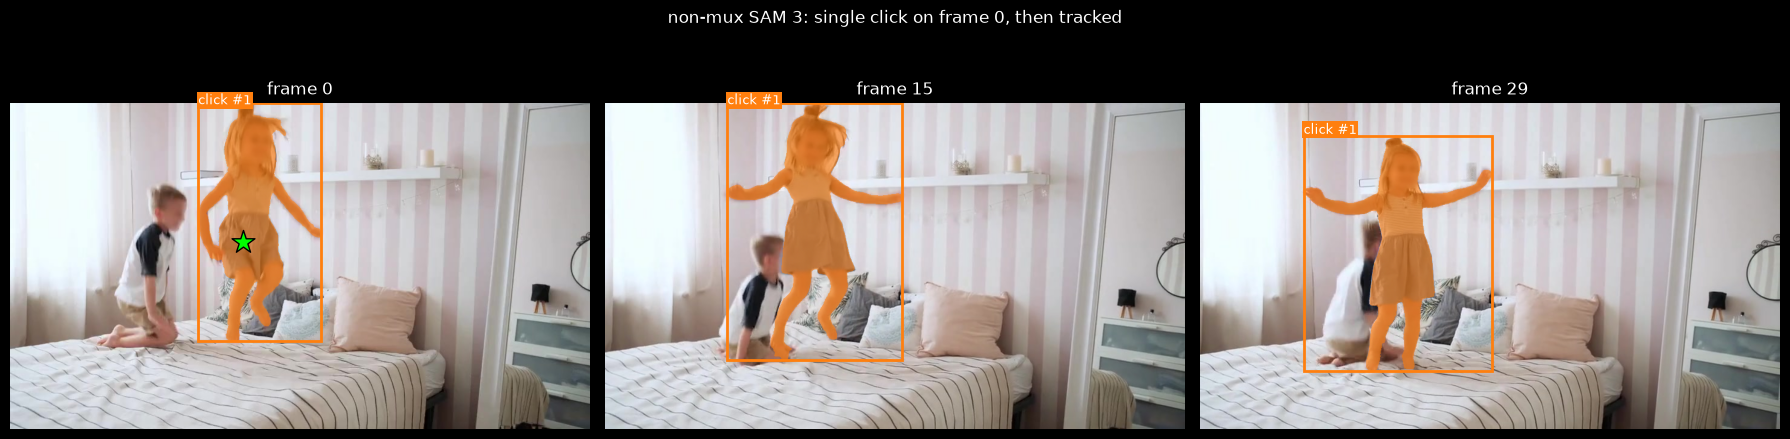

In [6]:
CLICK_XY = (385.0, 230.0)  # a kid in the 960x540 frame

click = GeometryPrompt(
    obj_id=1,
    points_coords=torch.tensor([list(CLICK_XY)], device=device),
    points_labels=torch.tensor([1], device=device),
)
state = Sam3VideoPredictorState(video_hw=(H, W))  # fresh state, NO set_concept
click_track = collect(video_predictor, state, frames, geometry_prompts_frame0=[click])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("non-mux SAM 3: single click on frame 0, then tracked")
for ax, i in zip(axes, [0, 15, 29]):
    ax.set_title(f"frame {i}")
    ax.imshow(frames[i])
    ax.axis("off")
    for obj_id, o in click_track[i].items():
        show_mask(o["mask"], ax, obj_id=obj_id)
        if o["box"] is not None:
            show_box(o["box"], ax, obj_id=obj_id, label=f"click #{obj_id}")
    if i == 0:
        ax.scatter(*CLICK_XY, color="lime", marker="*", s=300, edgecolor="black", zorder=5)
plt.tight_layout()
plt.show()

### Box prompt, mode 1: detection hint (upstream's box API)

A box needs no text: with no concept set, the predictor encodes the lineage's placeholder
caption (`"visual"` for base SAM 3, `"<text placeholder>"` for the 3.1 multiplex — upstream
picks a different text id per lineage) and lets the box bias detection through the geometric
slot. That caption then keeps running detection on every later frame, exactly as upstream's
`add_prompt` writes the text id into all frames.

So the box does **not** select an object — it hints one. Below, one box on the girl yields
**two** tracked objects, the boy included, because the placeholder caption matches him too.
That is upstream's behaviour, measured with this exact box on the reference `sam3.pt`
(`n=2 ids=[0, 1]` on every frame). The next section shows the other mode, which does select.

objects by frame: {0: [0, 1], 1: [0, 1], 2: [0, 1]}


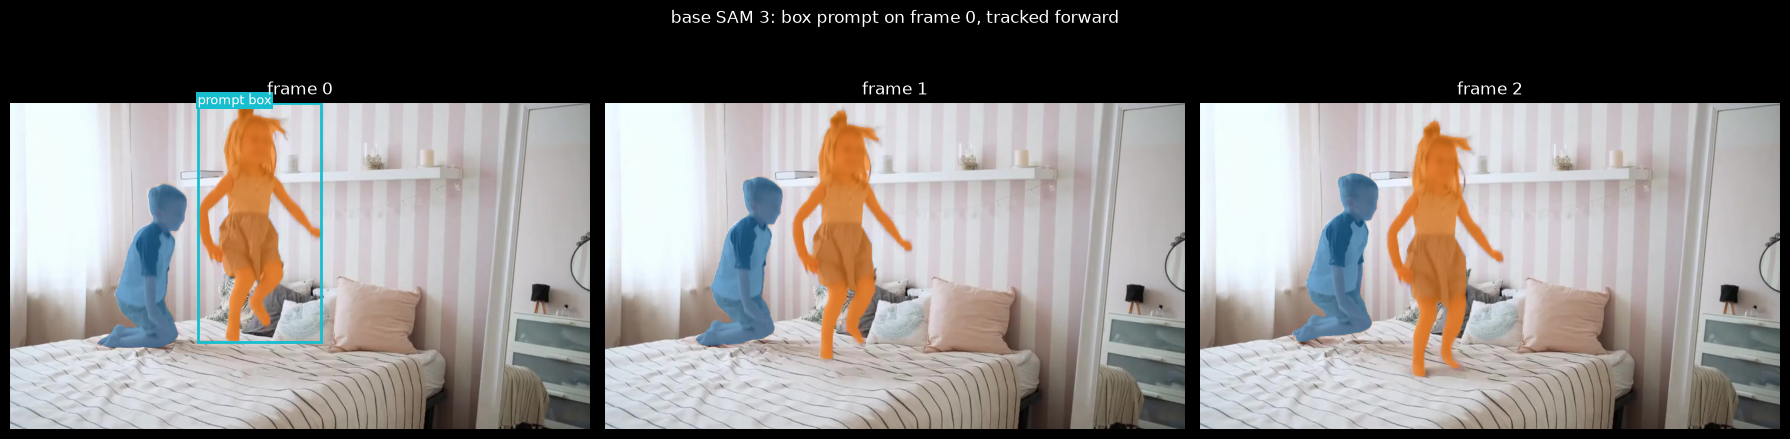

In [7]:
BOX_XYXY = [310, 0.0, 515, 396]  # the girl, native 960x540 pixels

st_base_box = Sam3VideoPredictorState(video_hw=(H, W))  # no set_concept
base_box = GeometryPrompt(obj_id=1, boxes=torch.tensor([BOX_XYXY], device=device))
base_box_track = collect(video_predictor, st_base_box, frames,
                         geometry_prompts_frame0=[base_box])
print("objects by frame:", {i: sorted(base_box_track[i]) for i in (0, 1, 2)})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("base SAM 3: box prompt on frame 0, tracked forward")
for ax, i in zip(axes, [0, 1, 2]):
    ax.set_title(f"frame {i}")
    ax.imshow(frames[i])
    ax.axis("off")
    for obj_id, o in base_box_track[i].items():
        show_mask(o["mask"], ax, obj_id=obj_id)
    if i == 0:
        show_box(torch.tensor(BOX_XYXY), ax, obj_id=9, label="prompt box")
plt.tight_layout()
plt.show()

### Box prompt, mode 2: interactive VOS (box as corner points)

Pass the box's two corners as *points* with the SAM 2 corner labels — `2` for the top-left,
`3` for the bottom-right — and the prompt takes the tracker route instead of the detector
route. One object, the one you boxed, tracked to the end of the clip.

The two modes are genuinely different contracts, not two spellings of one thing:

| | mode 1: `boxes=` (detection hint) | mode 2: corner points (interactive VOS) |
|---|---|---|
| where the prompt goes | detector's geometric slot, prompt frame only | tracker's prompt encoder, as two corner embeddings |
| detection afterwards | ON for every frame, under the placeholder caption | never runs (no concept is adopted) |
| how many objects | every instance the caption matches, boxed one included | exactly one, under the `obj_id` you chose |
| new objects mid-clip | yes, the detector keeps spawning | no |
| object ids | assigned by the detector | yours |
| lifecycle | confirm / suppress / hotstart kill all apply | force-confirmed, exempt from the kill |
| upstream equivalent | `add_prompt(boxes_xywh=...)` — parity-tested | SAM 2's box VOS; upstream SAM 3 routes boxes only to the detector |

Mode 2 is the SAM 2 heritage path that the shared tracker still implements, so it is *not*
what upstream's box API does — reach for it when you want the "select this object" contract,
and for anything measured against a SAM 3 golden, use mode 1.

A third option, if you want mode 1's detector but only one object out: keep the box, find the
id whose frame-0 mask overlaps it, and filter the rest out of each frame's dict. The other
tracklets still cost compute and memory that way, which is why the corner-point route is the
better fit when one object is all you need.

objects by frame: {0: [1], 15: [1], 29: [1]}


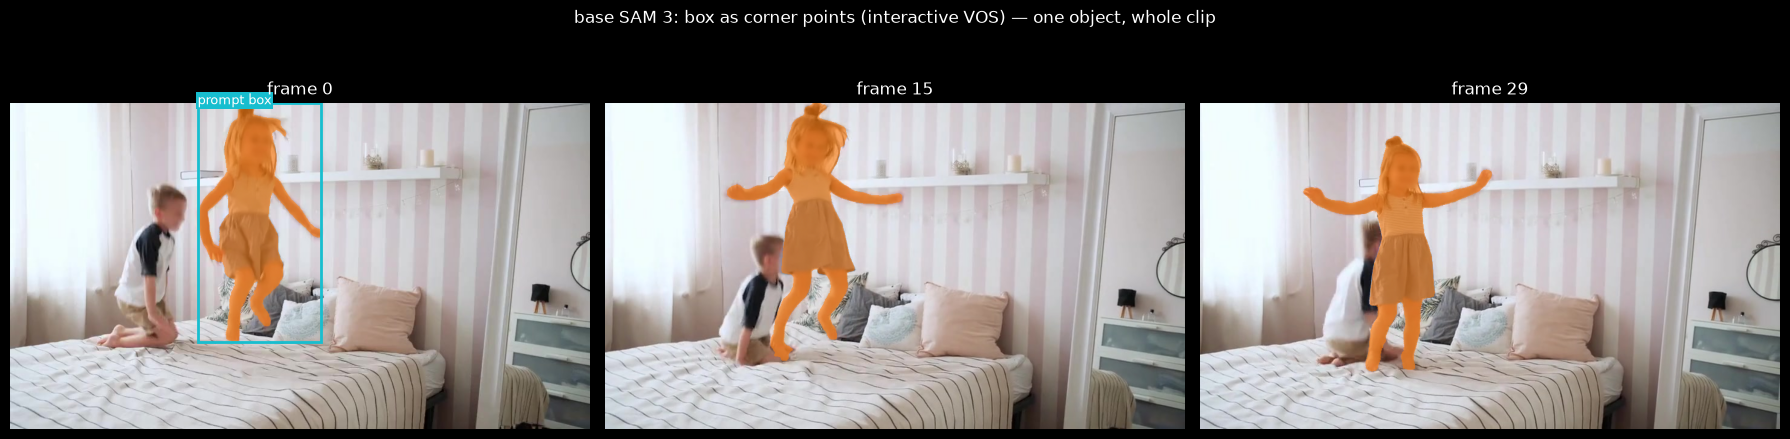

In [8]:
# Same box as above, but expressed as tracker corner points: labels 2 = top-left, 3 = bottom-right.
x0, y0, x1, y1 = BOX_XYXY
st_box_vos = Sam3VideoPredictorState(video_hw=(H, W))  # no set_concept
box_vos = GeometryPrompt(
    obj_id=1,
    points_coords=torch.tensor([[x0, y0], [x1, y1]], device=device),
    points_labels=torch.tensor([2, 3], device=device),
)
vos_track = collect(video_predictor, st_box_vos, frames, geometry_prompts_frame0=[box_vos])
print("objects by frame:", {i: sorted(vos_track[i]) for i in (0, 15, 29)})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("base SAM 3: box as corner points (interactive VOS) — one object, whole clip")
for ax, i in zip(axes, [0, 15, 29]):
    ax.set_title(f"frame {i}")
    ax.imshow(frames[i])
    ax.axis("off")
    for obj_id, o in vos_track[i].items():
        show_mask(o["mask"], ax, obj_id=obj_id)
    if i == 0:
        show_box(torch.tensor(BOX_XYXY), ax, obj_id=9, label="prompt box")
plt.tight_layout()
plt.show()

## 2. Non-multiplex SAM 3 — image detection (genuine DETR boxes)

The video tracker has no box head, so the boxes above are mask-derived. To see SAM 3's **real
predicted boxes**, run the image detector on a single frame: `Sam3DetectionResult.boxes` are the
raw DETR `pred_boxes` (cxcywh -> xyxy, scaled to pixels).

2 detection(s) | presence=0.970
boxes (xyxy px) = raw DETR pred_boxes:
[[146.6 134.7 291.  405.7]
 [310.3  -1.  515.2 396.8]]


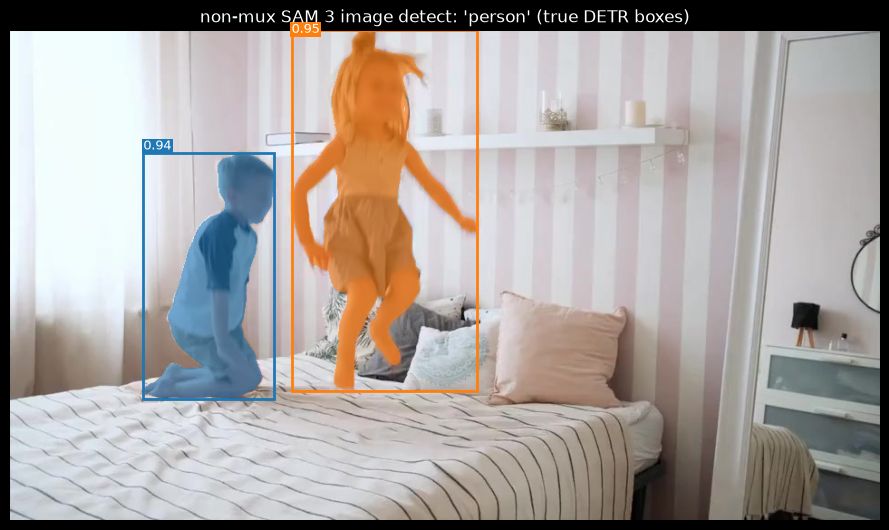

In [9]:
from sam.build_sam import build_sam3

del video_predictor, state  # free the video weights first (SAM 3 is large)
torch.cuda.empty_cache()

image_predictor = build_sam3(
    config_file="configs/sam3/sam3.yaml", ckpt_path="checkpoints/sam3.pt", device="cuda",
)

det = image_predictor.predict(frames[0], ConceptPrompt(CONCEPT), confidence_threshold=0.5)
print(f"{det.num_detections} detection(s) | presence={det.presence:.3f}")
print("boxes (xyxy px) = raw DETR pred_boxes:")
print(det.boxes.cpu().numpy().round(1))

fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.set_title(f"non-mux SAM 3 image detect: '{CONCEPT}' (true DETR boxes)")
ax.imshow(frames[0])
ax.axis("off")
for i in range(det.num_detections):
    show_mask((det.masks_logits[i] > 0).cpu(), ax, obj_id=i)
    show_box(det.boxes[i], ax, obj_id=i, label=f"{det.scores[i]:.2f}")
plt.tight_layout()
plt.show()

### Text-prompt variety & confidence threshold

The concept is just a phrase — swap it to detect anything. `confidence_threshold` trades recall
for precision (presence-weighted score gate).

In [10]:
for phrase in ["person", "bed", "lamp", "window", "picture frame"]:
    d = image_predictor.predict(frames[0], ConceptPrompt(phrase), confidence_threshold=0.5)
    print(f"{phrase:<14} -> {d.num_detections:2d} detection(s) | presence={d.presence:.3f}")

print("\nconfidence_threshold sweep for 'person':")
for thr in [0.3, 0.5, 0.7, 0.9]:
    d = image_predictor.predict(frames[0], ConceptPrompt("person"), confidence_threshold=thr)
    print(f"  thr={thr} -> {d.num_detections} detection(s)")

person         ->  2 detection(s) | presence=0.970


bed            ->  1 detection(s) | presence=0.965


lamp           ->  1 detection(s) | presence=0.745


window         ->  0 detection(s) | presence=0.050


picture frame  ->  0 detection(s) | presence=0.036

confidence_threshold sweep for 'person':


  thr=0.3 -> 2 detection(s)


  thr=0.5 -> 2 detection(s)


  thr=0.7 -> 2 detection(s)


  thr=0.9 -> 2 detection(s)


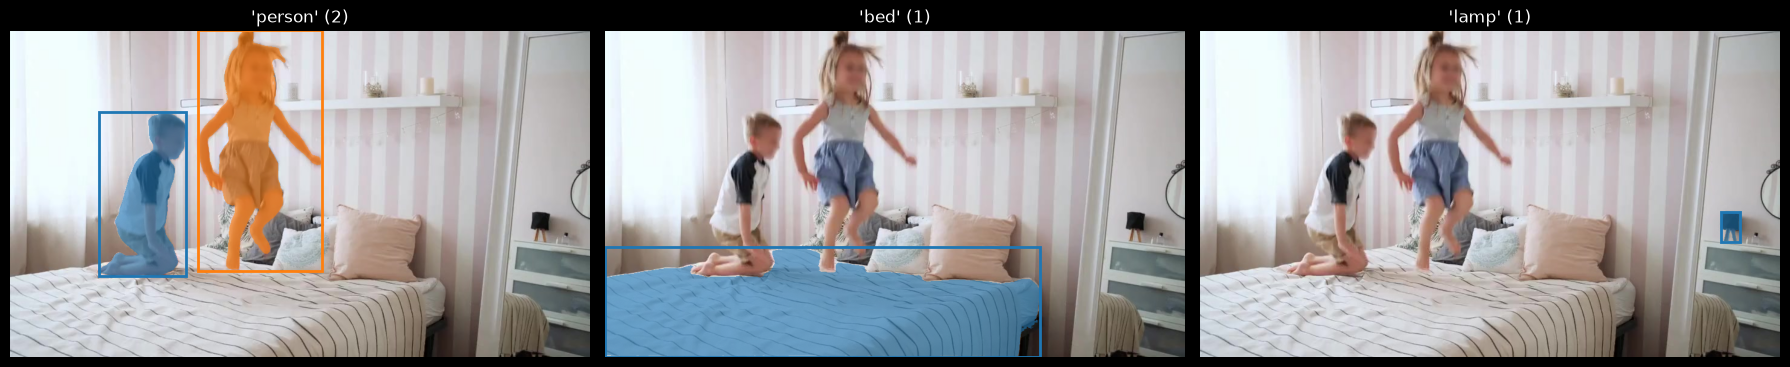

In [11]:
concepts = ["person", "bed", "lamp"]
fig, axes = plt.subplots(1, len(concepts), figsize=(6 * len(concepts), 5))
for ax, phrase in zip(np.atleast_1d(axes), concepts):
    d = image_predictor.predict(frames[0], ConceptPrompt(phrase), confidence_threshold=0.5)
    ax.set_title(f"'{phrase}' ({d.num_detections})")
    ax.imshow(frames[0])
    ax.axis("off")
    for i in range(d.num_detections):
        show_mask((d.masks_logits[i] > 0).cpu(), ax, obj_id=i)
        show_box(d.boxes[i], ax, obj_id=i)
plt.tight_layout()
plt.show()

### Negative boxes — "everything matching, except this one"

`boxes_labels` gives each box a sign: `1` positive (the default when omitted), `0` negative.
The label indexes the geometry encoder's `nn.Embedding(2, d)`, so the sign really is part of
the prompt rather than a filter applied afterwards.

How strongly it bites depends on the detector. Below, on the **base** detector, the sign
moves the concept's presence and every score (positive pushes presence to ~1.0, negative
drops it to ~0.83). On the **3.1 multiplex** detector the same box at
`[300, 150, 470, 420]` on "person" removes the enclosed detection outright — 3 detections at
presence 0.99999 positive, 2 at 0.8615 negative, with the boxed person gone
(`tests/parity/test_sam3_box_prompt_parity.py`).

In [12]:
from sam.prompts import ConceptPrompt, GeometryPrompt

frame0 = frames[0]
for label, name in [(None, "no box"), (1, "positive box"), (0, "negative box")]:
    geom = None
    if label is not None:
        geom = GeometryPrompt(
            obj_id=1,
            boxes=torch.tensor([[300.0, 150.0, 470.0, 420.0]]),
            boxes_labels=None if label == 1 else torch.tensor([label]),
        )
    det = image_predictor.predict(frame0, ConceptPrompt("person"),
                                  confidence_threshold=0.5, geometry=geom)
    scores = [round(float(s), 3) for s in det.scores.tolist()]
    print(f"{name:15s} -> {det.num_detections} detections, "
          f"presence {det.presence:.4f}, scores {scores}")

no box          -> 2 detections, presence 0.9702, scores [0.938, 0.949]


positive box    -> 2 detections, presence 1.0000, scores [0.91, 0.926]


negative box    -> 2 detections, presence 0.8344, scores [0.812, 0.785]


## 3. Multiplex SAM 3.1 — text-concept video tracking

Same `set_concept` / `forward` API, but `build_sam3_multiplex_video_predictor` swaps in the
SAM 3.1 tri-neck encoder, joint-score detector, and the multiplex tracker (objects packed into
K=16 buckets, tracked jointly). Config `configs/sam3/sam3.1.yaml`, checkpoint
`checkpoints/sam3.1_multiplex.pt` (~3.3 GB). Clicks and boxes work here as on the base
predictor; only mask prompts raise `NotImplementedError` (neither checkpoint ships
`mask_encoder` weights).

In [13]:
from sam.build_sam import build_sam3_multiplex_video_predictor

del image_predictor  # free non-mux weights before loading the larger mux checkpoint
torch.cuda.empty_cache()

mux_predictor = build_sam3_multiplex_video_predictor(
    config_file="configs/sam3/sam3.1.yaml",
    ckpt_path="checkpoints/sam3.1_multiplex.pt",
    device="cuda",
)
print(f"loaded: {sum(p.numel() for p in mux_predictor.parameters()) / 1e6:.0f}M params")

loaded: 873M params


tracked ids on last frame: [0, 1]


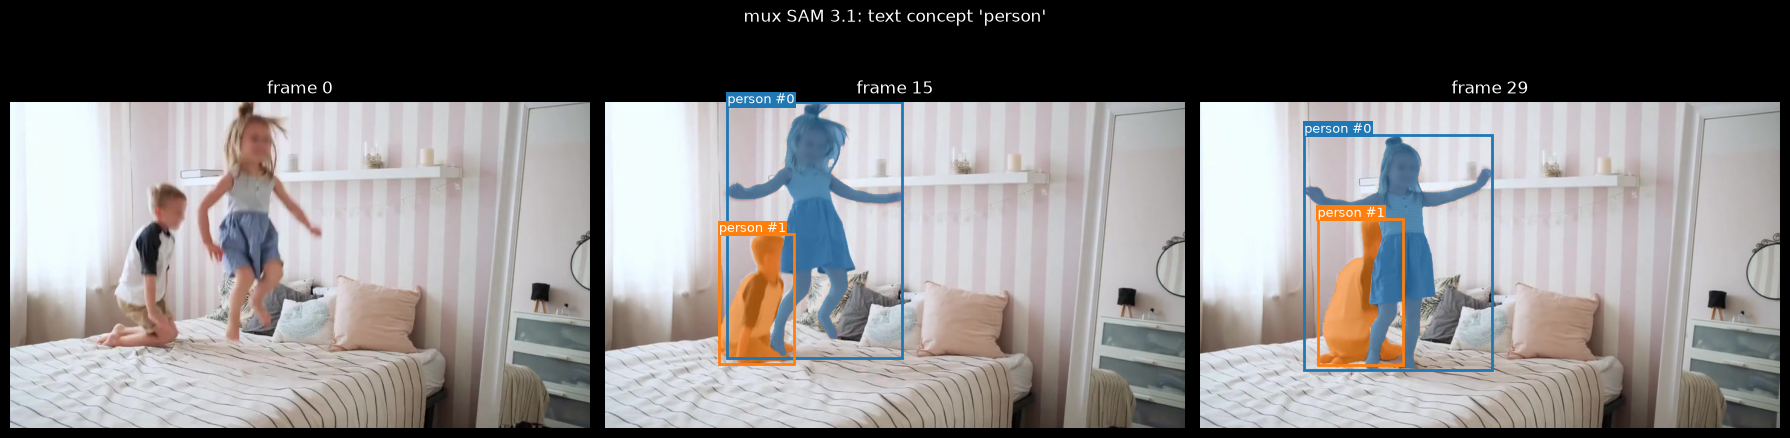

In [14]:
state = Sam3VideoPredictorState(video_hw=(H, W))
mux_predictor.set_concept(state, ConceptPrompt(CONCEPT))
mux_track = collect(mux_predictor, state, frames)
print(f"tracked ids on last frame: {sorted(mux_track[-1])}")
show_tracking(frames, mux_track, f"mux SAM 3.1: text concept '{CONCEPT}'", CONCEPT)

### Interactive seed-frame click (mux, text-free)

A positive click on frame 0 seeds an object, then it tracks forward — the SAM 3.1
interactive VOS path (`interactive_sam_prompt_encoder` + `interactive_sam_mask_decoder`),
no text concept. Box output is the mask-derived box, as before.

tracked ids on last frame: [1]


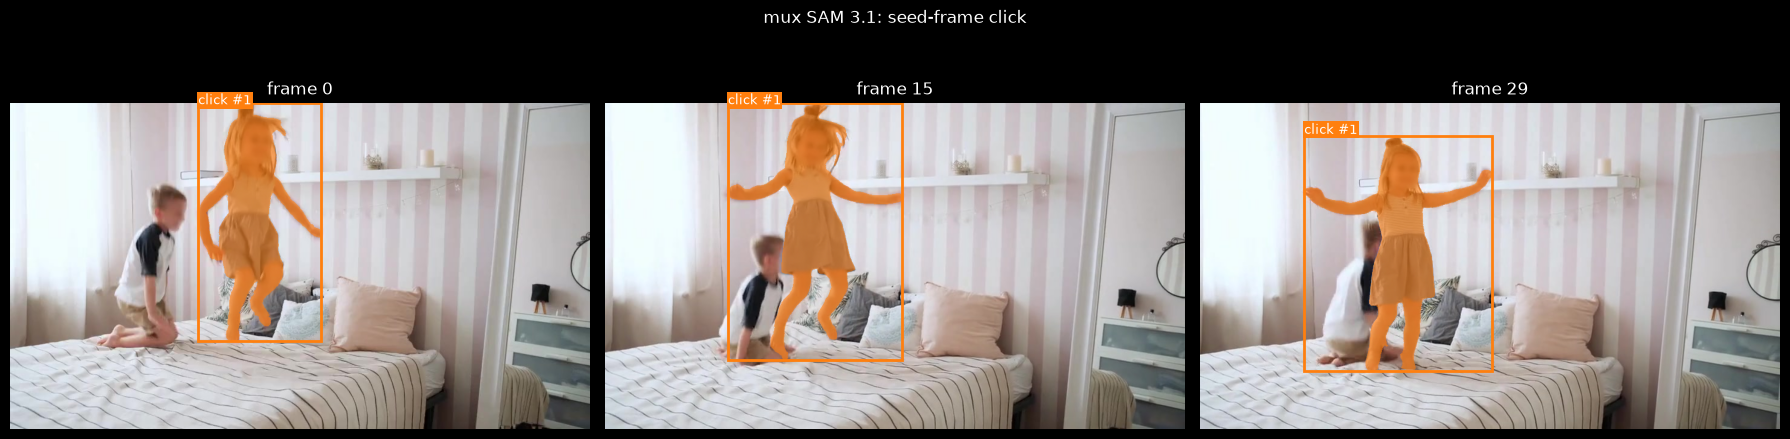

In [15]:
st_click = Sam3VideoPredictorState(video_hw=(H, W))
click = GeometryPrompt(
    obj_id=1,
    points_coords=torch.tensor([[385.0, 230.0]], device=device),
    points_labels=torch.tensor([1], device=device),
)
mux_click = collect(mux_predictor, st_click, frames, geometry_prompts_frame0=[click])
print(f"tracked ids on last frame: {sorted(mux_click[-1])}")
show_tracking(frames, mux_click, "mux SAM 3.1: seed-frame click", "click")

### Model-find: mid-stream detector spawn (dynamic add)

Text `"person"` on `dance.mp4`: the camera pans, a dancer leaves frame, then
**re-enters mid-video** and the detector auto-spawns a tracklet — the multiplex
state grows mid-stream (no re-seed). Watch the object count drop then rise.

tracked-object count by frame: {0: 0, 60: 3, 90: 2, 96: 3, 100: 3}


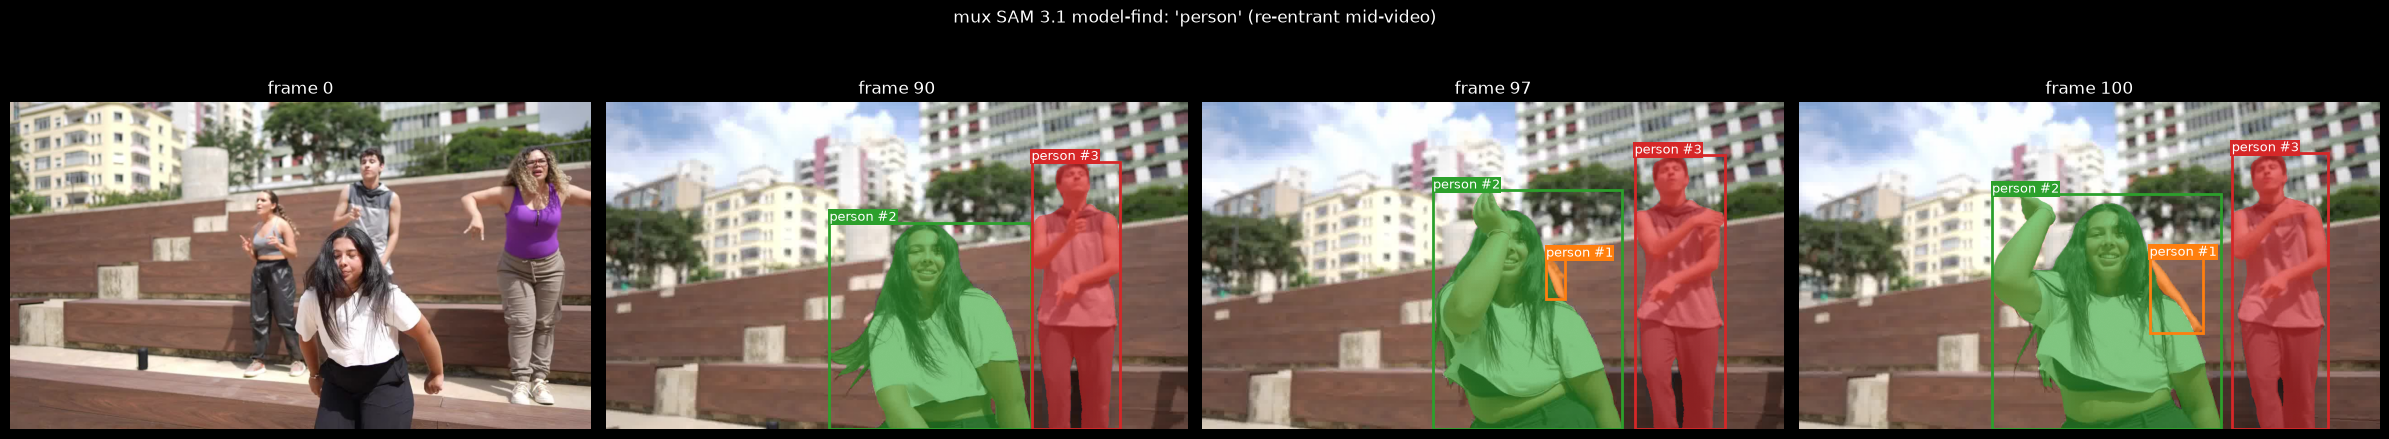

In [16]:
dance = [
    np.asarray(Image.open(f"notebooks/videos/dance/{i:05d}.jpg").convert("RGB"))
    for i in range(101)
]
dh, dw, _ = dance[0].shape
st_mf = Sam3VideoPredictorState(video_hw=(dh, dw))
mux_predictor.set_concept(st_mf, ConceptPrompt("person"))
mf = collect(mux_predictor, st_mf, dance)
print("tracked-object count by frame:",
      {i: len(mf[i]) for i in (0, 60, 90, 96, 100)})
show_tracking(dance, mf, "mux SAM 3.1 model-find: 'person' (re-entrant mid-video)",
              "person", idxs=[0, 90, 97, 100])

### Box prompt (video): seed a detection by a box

A box `GeometryPrompt` on frame 0 biases that frame's detector (GEOMETRIC slot) and seeds a
tracklet — no text concept needed. Two things differ from the base predictor above:

* A box-only prompt is brittle here, because detection runs the placeholder caption rather
  than a concept. The box wants generous margin around the object: a tight crop of the same
  child scores under the 0.5 joint-score gate (presence 0.07 vs 0.92 with margin) and spawns
  nothing, and boxes that do spawn sometimes return the box's *background* region instead of
  the child — including the box the parity golden was captured with.
* The seeded tracklet is visible only on the prompt frame: no later detection re-matches it,
  so the object stays PENDING and its `keep_alive` decays. The default `Emit.CONFIRMED` hides
  it on every frame — upstream's behaviour too
  (`tests/parity/test_sam3p1_video_box_parity.py`). The cell below measures in `Emit.VISIBLE`
  and plots the seed frame; for a box that keeps tracking, use the base predictor.

objects by frame: {0: [], 1: [], 2: []}


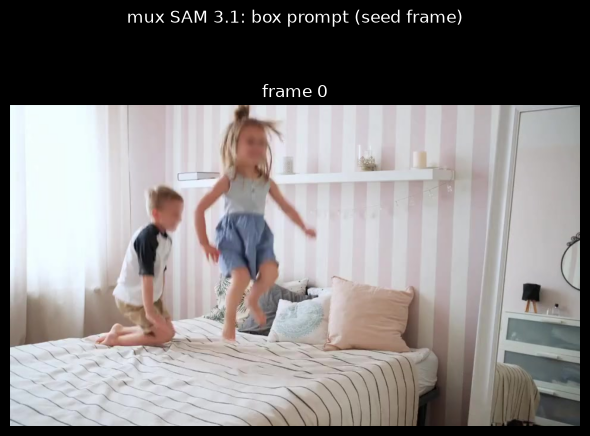

In [17]:
from sam.results import Emit

st_box = Sam3VideoPredictorState(video_hw=(H, W))
box = GeometryPrompt(obj_id=1, boxes=torch.tensor([BOX_XYXY], device=device))
mux_predictor.emit = Emit.VISIBLE  # CONFIRMED hides the box seed (see above)
box_track = collect(mux_predictor, st_box, frames, geometry_prompts_frame0=[box])
mux_predictor.emit = Emit.CONFIRMED  # restore the default
print("objects by frame:", {i: sorted(box_track[i]) for i in (0, 1, 2)})
show_tracking(frames, box_track, "mux SAM 3.1: box prompt (seed frame)", "box", idxs=[0])


## Output policy — when does a tracked object become visible?

Every alive tracklet is propagated and keeps its memory no matter the policy; `emit` only
decides what `forward` returns (empty masks are always dropped). The default is causal:

| mode | shows |
|---|---|
| `Emit.CONFIRMED` (default) | objects matched by a detection for 3 consecutive frames |
| `Emit.VISIBLE` | alive and not suppressed — what upstream's goldens show |
| `Emit.ALIVE` | every tracklet, suppressed ones included |

`CONFIRMED` means a one-frame detector false positive never reaches you, at the cost of an
object's first frames. Upstream decides visibility non-causally (it buffers 15 frames of
output), which a streaming predictor cannot reproduce — so the policy is the causal half of
that rule, and every `MaskletResult` also carries its `tracklet_state` if you want to build
your own.

In [18]:
from sam.results import Emit

for mode in (Emit.CONFIRMED, Emit.VISIBLE, Emit.ALIVE):
    mux_predictor.emit = mode
    st = Sam3VideoPredictorState(video_hw=(H, W))
    mux_predictor.set_concept(st, ConceptPrompt("person"))
    counts = []
    with torch.inference_mode():
        for i, fr in enumerate(frames[:8]):
            out = mux_predictor.forward(st, i, fr)
            counts.append(len(out))
    print(f"{mode.value:10s} objects per frame (0-7): {counts}")

mux_predictor.emit = Emit.CONFIRMED  # restore the default

confirmed  objects per frame (0-7): [0, 0, 2, 2, 2, 2, 2, 2]


visible    objects per frame (0-7): [2, 2, 2, 2, 2, 2, 2, 2]


alive      objects per frame (0-7): [2, 2, 2, 2, 2, 2, 2, 2]


## Several concepts at once

Upstream has no concurrent multi-concept path: its only multi-concept code loops the phrases,
propagates the whole video once per phrase, and offsets the object ids. That is N independent
sessions — which the streaming API already gives you, at the same cost, by keeping one state
per concept. Sharing a single session would *not* be equivalent: association matches all
detections against all tracks, so one concept's detection could capture another's tracklet.

{'person': [0, 0, 2, 2, 2, 2, 2, 2], 'bed': [0, 0, 1, 1, 1, 1, 1, 1]}


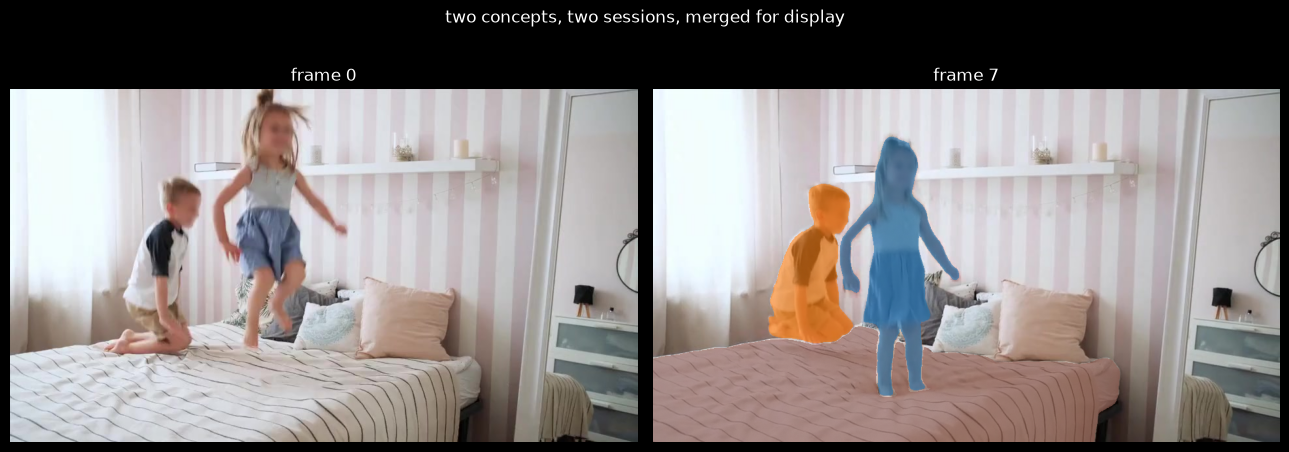

In [19]:
CONCEPTS = ["person", "bed"]

states = {}
for c in CONCEPTS:
    s = Sam3VideoPredictorState(video_hw=(H, W))
    mux_predictor.set_concept(s, ConceptPrompt(c))
    states[c] = s

per_concept = {c: [] for c in CONCEPTS}
with torch.inference_mode():
    for i, fr in enumerate(frames[:8]):
        for c, s in states.items():
            out = mux_predictor.forward(s, i, fr)
            per_concept[c].append({
                oid: (r.best_mask_logits[0, 0] > 0).cpu() for oid, r in out.items()
            })

offset, merged = 0, []
for i in range(8):
    frame_objs = {}
    for c in CONCEPTS:
        for oid, m in per_concept[c][i].items():
            frame_objs[(c, oid)] = m
    merged.append(frame_objs)
print({c: [len(f) for f in per_concept[c]] for c in CONCEPTS})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("two concepts, two sessions, merged for display")
for ax, i in zip(axes, [0, 7]):
    ax.set_title(f"frame {i}")
    ax.imshow(frames[i])
    ax.axis("off")
    for k, ((c, oid), m) in enumerate(merged[i].items()):
        show_mask(m, ax, obj_id=CONCEPTS.index(c) * 5 + oid)
plt.tight_layout()
plt.show()

## Summary

- **Text concept** drives all three paths (base image / base video / multiplex video) through
  `ConceptPrompt(text)`.
- **Geometry** (`GeometryPrompt`) is supported on both video predictors and the image
  predictor, along **two different contracts**. A `boxes=` prompt is a *detection hint*: it
  biases the prompt frame through the geometry encoder (`boxes_labels` signs it positive or
  negative) and leaves detection running under a placeholder caption, so every matching
  instance is tracked, not just the boxed one. Points are *interactive VOS*: they seed exactly
  one object through the tracker, detection never runs, and the object is force-confirmed and
  exempt from the hotstart kill. A box can take the second route too, as two corner points
  (labels `2`/`3`) — SAM 2 semantics rather than upstream SAM 3's box API. Mask prompts
  raise `NotImplementedError` — neither checkpoint ships `mask_encoder` weights.
- **Prompts are not restricted to frame 0**: a `GeometryPrompt` on a later frame adds that
  object mid-stream, and the detector spawns new instances on its own as they appear. An
  object that leaves and re-enters keeps its id (upstream issues a new one).
- **Genuine boxes** come from the image detector (`Sam3DetectionResult.boxes`); the boxes
  drawn for video above are `masks_to_boxes` of the output masks, derived in this notebook.
- **`Emit`** selects the display policy without changing tracking, and every `MaskletResult`
  carries its `tracklet_state`.
- **Several concepts** = one state per concept, which is exactly what upstream's own
  multi-concept path does.
- `ConceptPrompt` carries only the text. There is no negative-phrase field and no exemplar
  field: upstream encodes an optional `additional_text` but never consumes it, and its
  VISUAL-slot embedding has no producer in any released code path — reference geometry is a
  `GeometryPrompt` box/point instead.